# Mount Drive & Clone Repo

In [1]:
# Load Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os, sys

os.chdir('/content')
!rm -rf Bone-Fracture-Detection
!git clone https://github.com/sabinshamsul/Bone-Fracture-Detection.git
os.chdir('/content/Bone-Fracture-Detection')
sys.path.append('/content/Bone-Fracture-Detection')

print("Repo cloned & ready!")
print("Files in src/:", os.listdir('src'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'Bone-Fracture-Detection'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 74 (delta 42), reused 44 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 13.50 KiB | 3.38 MiB/s, done.
Resolving deltas: 100% (42/42), done.
Repo cloned & ready!
Files in src/: ['predict.py', 'preprocess.py', 'model.py', 'gradcam.py']


# Copy Dataset from Drive

In [2]:
import shutil, os

os.chdir('/content/Bone-Fracture-Detection')

drive_dataset_path = '/content/drive/MyDrive/FracAtlas'
local_dataset_path = '/content/Bone-Fracture-Detection/data/FracAtlas'

if not os.path.exists(local_dataset_path):
  print("Copying dataset from Google Drive")
  shutil.copytree(drive_dataset_path, local_dataset_path)
  print("Dataset copied successfully")
else:
  print("Dataset already exists locally")

Copying dataset from Google Drive
Dataset copied successfully


# Install Dependencies

In [3]:
!pip install -q tensorflow opencv-python scikit-learn seaborn matplotlib
print("Dependencies installed")

Dependencies installed


# Load & Split Dataset

In [4]:
import sys, os
os.chdir('/content/Bone-Fracture-Detection')
sys.path.append('/content/Bone-Fracture-Detection')

from src.preprocess import get_valid_image_paths, create_tf_dataset
from sklearn.model_selection import train_test_split
import numpy as np

data_dir = '/content/Bone-Fracture-Detection/data/FracAtlas'

# Step 1 — Pre-filter corrupted images
print("Scanning for corrupted images...")
all_paths, all_labels = get_valid_image_paths(data_dir)

# Step 2 — Split into train / val / test
all_labels_arr = np.array(all_labels)

# First split: 70% train, 30% temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.3,
    random_state=42,
    stratify=all_labels
)

# Second split: 15% val, 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"\nTraining:   {len(train_paths)} images")
print(f"Validation: {len(val_paths)} images")
print(f"Test:       {len(test_paths)} images")

# Step 3 — Create tf.data datasets
train_dataset = create_tf_dataset(
    train_paths, train_labels,
    batch_size=32, shuffle=True
)
val_dataset = create_tf_dataset(
    val_paths, val_labels,
    batch_size=32, shuffle=False
)
test_dataset = create_tf_dataset(
    test_paths, test_labels,
    batch_size=32, shuffle=False
)

print("\n Datasets ready!")

Scanning for corrupted images...
✅ Valid images: 4083
❌ Skipped corrupted: 0

Training:   2858 images
Validation: 612 images
Test:       613 images

 Datasets ready!


# Build Model

In [5]:
import sys, os
os.chdir('/content/Bone-Fracture-Detection')
sys.path.append('/content/Bone-Fracture-Detection')

from src.model import build_model

# Build EfficientNetB0 Model
model, base_model = build_model( (224, 224, 3))

#Print summary
model.summary()

print(f"\nModel built successfully")
print(f"\nTotal layers: {len(model.layers)}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Model built successfully

Total layers: 7


In [6]:
import numpy as np

# Check 1 — Are datasets actually loading images correctly?
print("=" * 50)
print("DATASET DIAGNOSTIC")
print("=" * 50)

# Take one batch and inspect it
for images, labels in train_dataset.take(1):
    print(f"Batch shape: {images.shape}")
    print(f"Labels in batch: {labels.numpy()}")
    print(f"Unique labels: {np.unique(labels.numpy())}")
    print(f"Min pixel: {images.numpy().min():.3f}")
    print(f"Max pixel: {images.numpy().max():.3f}")
    print(f"Fractured in batch: {labels.numpy().sum()}")
    print(f"Non-fractured in batch: {(1-labels.numpy()).sum()}")

# Check 2 — Class weight values
print("\n" + "=" * 50)
print("CLASS BALANCE CHECK")
print("=" * 50)
print(f"Train labels — Fractured: {sum(train_labels)}")
print(f"Train labels — Non-fractured: {len(train_labels) - sum(train_labels)}")

# Check 3 — Model output before training
print("\n" + "=" * 50)
print("MODEL SANITY CHECK")
print("=" * 50)
for images, labels in test_dataset.take(1):
    preds = model.predict(images)
    print(f"Raw predictions (first 10): {preds[:10].flatten()}")
    print(f"All same value? {np.allclose(preds, preds[0])}")

DATASET DIAGNOSTIC
Batch shape: (32, 224, 224, 3)
Labels in batch: [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
Unique labels: [0 1]
Min pixel: 0.000
Max pixel: 255.000
Fractured in batch: 2
Non-fractured in batch: 30

CLASS BALANCE CHECK
Train labels — Fractured: 502
Train labels — Non-fractured: 2356

MODEL SANITY CHECK
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Raw predictions (first 10): [0.7196769  0.4551866  0.627798   0.6113088  0.53357023 0.6945928
 0.61343306 0.53276956 0.50034875 0.6340241 ]
All same value? False


In [7]:
import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Define class weights here directly
classes = np.unique(train_labels)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)
class_weight_dict = dict(zip(classes.tolist(), weights.tolist()))
print(f"Class weights: {class_weight_dict}")

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# Run just 3 epochs to see what's happening
history_test = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3,
    class_weight=class_weight_dict,
    verbose=1
)

print("\nTraining loss per epoch:")
print(history_test.history['loss'])
print("\nValidation AUC per epoch:")
print(history_test.history['val_auc'])
print("\nTraining accuracy per epoch:")
print(history_test.history['accuracy'])

Class weights: {0: 0.6065365025466893, 1: 2.846613545816733}
Epoch 1/3
90/90 ━━━━━━━━━━━━━━━━━━━━ 296s 3s/step - accuracy: 0.7208 - auc: 0.7864 - loss: 0.5599 - val_accuracy: 0.7925 - val_auc: 0.8153 - val_loss: 0.4321
Epoch 2/3
90/90 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.8023 - auc: 0.8779 - loss: 0.4414 - val_accuracy: 0.8284 - val_auc: 0.8508 - val_loss: 0.3704
Epoch 3/3
90/90 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.8142 - auc: 0.8982 - loss: 0.4047 - val_accuracy: 0.8137 - val_auc: 0.8582 - val_loss: 0.4086

Training loss per epoch:
[0.5598651766777039, 0.44138768315315247, 0.4046853482723236]

Validation AUC per epoch:
[0.8153418898582458, 0.8507633805274963, 0.8582029938697815]

Training accuracy per epoch:
[0.7207837700843811, 0.8023093342781067, 0.8142057657241821]


In [8]:
import inspect
from src.model import build_model
print(inspect.getsource(build_model))

def build_model(input_shape=(224, 224, 3)):
    # Load EfficientNetB0 pretrained on ImageNet
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Freeze the base model
    base_model.trainable = False

    # Use functional API with training=False
    # This keeps BatchNorm in inference mode when base is frozen
    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.2)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=output)

    return model, base_model



In [9]:
import numpy as np

print("=" * 50)
print("VALIDATION DATASET LABEL CHECK")
print("=" * 50)

# Check labels in val_dataset
val_label_counts = []
for _, labels in val_dataset:
    val_label_counts.extend(labels.numpy().tolist())

val_label_counts = np.array(val_label_counts)
print(f"Val labels — total: {len(val_label_counts)}")
print(f"Val labels — Fractured (1): {val_label_counts.sum()}")
print(f"Val labels — Non-fractured (0): {(1-val_label_counts).sum()}")
print(f"Val labels — unique values: {np.unique(val_label_counts)}")

print("\n" + "=" * 50)
print("TRAIN DATASET LABEL CHECK")
print("=" * 50)

train_label_counts = []
for _, labels in train_dataset:
    train_label_counts.extend(labels.numpy().tolist())

train_label_counts = np.array(train_label_counts)
print(f"Train labels — total: {len(train_label_counts)}")
print(f"Train labels — Fractured (1): {train_label_counts.sum()}")
print(f"Train labels — Non-fractured (0): {(1-train_label_counts).sum()}")

print("\n" + "=" * 50)
print("SAMPLE PREDICTIONS vs ACTUAL")
print("=" * 50)

for images, labels in val_dataset.take(1):
    preds = model.predict(images)
    for i in range(10):
        print(f"Actual: {labels[i].numpy()} | "
              f"Predicted: {preds[i][0]:.4f} | "
              f"Predicted class: {1 if preds[i][0] > 0.5 else 0}")

VALIDATION DATASET LABEL CHECK
Val labels — total: 612
Val labels — Fractured (1): 107
Val labels — Non-fractured (0): 505
Val labels — unique values: [0 1]

TRAIN DATASET LABEL CHECK
Train labels — total: 2858
Train labels — Fractured (1): 502
Train labels — Non-fractured (0): 2356

SAMPLE PREDICTIONS vs ACTUAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Actual: 0 | Predicted: 0.0501 | Predicted class: 0
Actual: 0 | Predicted: 0.0649 | Predicted class: 0
Actual: 0 | Predicted: 0.2199 | Predicted class: 0
Actual: 0 | Predicted: 0.4506 | Predicted class: 0
Actual: 0 | Predicted: 0.2512 | Predicted class: 0
Actual: 0 | Predicted: 0.0433 | Predicted class: 0
Actual: 0 | Predicted: 0.1429 | Predicted class: 0
Actual: 0 | Predicted: 0.3228 | Predicted class: 0
Actual: 0 | Predicted: 0.0562 | Predicted class: 0
Actual: 0 | Predicted: 0.2980 | Predicted class: 0


# Train Model

In [10]:
import sys, os
os.chdir('/content/Bone-Fracture-Detection')
sys.path.append('/content/Bone-Fracture-Detection')

from src.model import compile_and_train

os.makedirs('models', exist_ok=True)

model, history1, history2 = compile_and_train(
    model, base_model,
    train_dataset, val_dataset,
    train_labels
)

print("\n Training complete!")

Class weights: {0: 0.6065365025466893, 1: 2.846613545816733}

STAGE 1: Training top layers only
Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 283s 3s/step - accuracy: 0.8240 - auc: 0.9092 - loss: 0.3807 - val_accuracy: 0.8039 - val_auc: 0.8593 - val_loss: 0.3989 - learning_rate: 0.0010
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - accuracy: 0.8450 - auc: 0.9221 - loss: 0.3562 - val_accuracy: 0.8284 - val_auc: 0.8571 - val_loss: 0.3990 - learning_rate: 0.0010
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.8628 - auc: 0.9407 - loss: 0.3135 - val_accuracy: 0.8235 - val_auc: 0.8649 - val_loss: 0.4181 - learning_rate: 0.0010
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 0.8611 - auc: 0.9412 - loss: 0.3096 - val_accuracy: 0.8497 - val_auc: 0.8681 - val_loss: 0.3264 - learning_rate: 0.0010
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 275s 3s/step - accuracy: 0.8747 - auc: 0.9487 - loss: 0.2926 - val_accuracy: 0.8627 - val_auc: 0.8727 - val_loss: 0.3413 - learning_ra

# Evaluation

FINAL EVALUATION ON TEST SET
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step

Classification Report:
               precision    recall  f1-score   support

Non-fractured       0.94      0.89      0.92       505
    Fractured       0.59      0.74      0.66       108

     accuracy                           0.86       613
    macro avg       0.77      0.82      0.79       613
 weighted avg       0.88      0.86      0.87       613



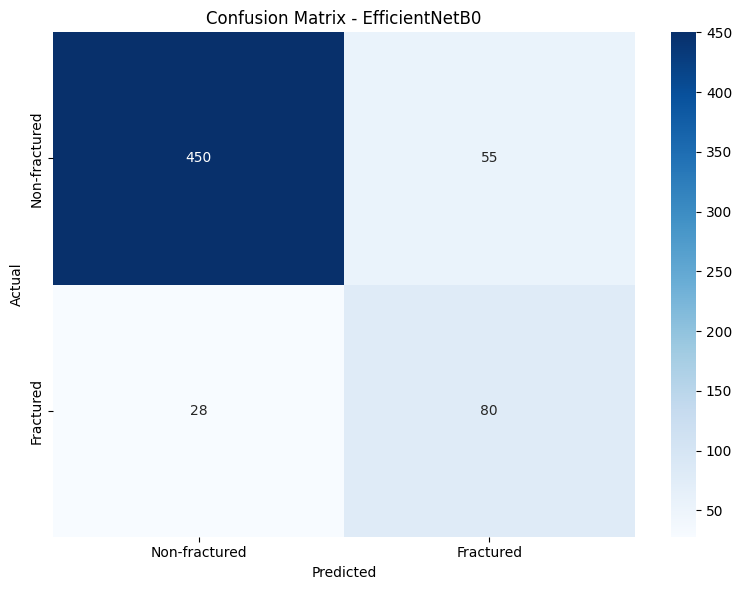

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np, os

os.chdir('/content/Bone-Fracture-Detection')

print("=" * 50)
print("FINAL EVALUATION ON TEST SET")
print("=" * 50)

y_pred_prob = model.predict(test_dataset)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_test = np.array(test_labels)

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Non-fractured", "Fractured"]
))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Non-fractured", "Fractured"],
    yticklabels=["Non-fractured", "Fractured"]
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix - EfficientNetB0")
plt.tight_layout()

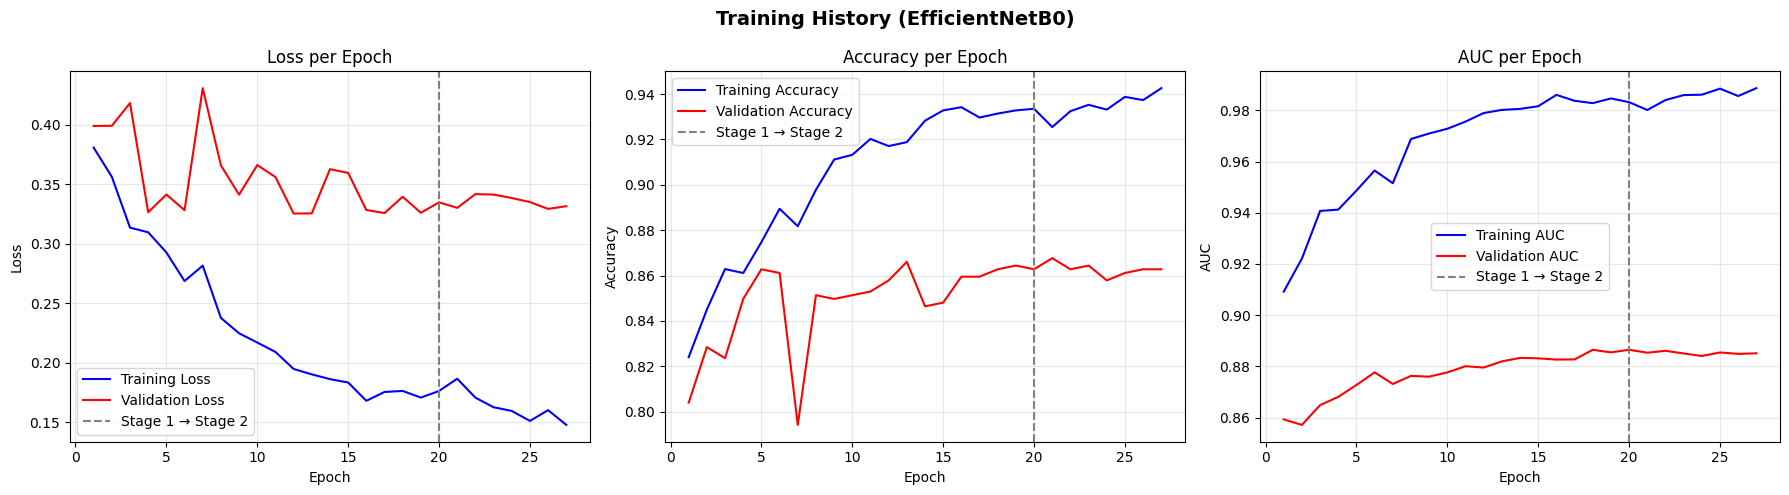

✅ Training history saved to results/training_history.png


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History (EfficientNetB0)", fontsize=14, fontweight='bold')

# Combine Stage 1 + Stage 2 history
train_loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

train_acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

train_auc = history1.history['auc'] + history2.history['auc']
val_auc = history1.history['val_auc'] + history2.history['val_auc']

epochs = range(1, len(train_loss) + 1)
stage1_end = len(history1.history['loss'])

# Plot 1 — Loss
axes[0].plot(epochs, train_loss, 'b-', label='Training Loss')
axes[0].plot(epochs, val_loss, 'r-', label='Validation Loss')
axes[0].axvline(x=stage1_end, color='gray', linestyle='--',
                label='Stage 1 → Stage 2')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Accuracy
axes[1].plot(epochs, train_acc, 'b-', label='Training Accuracy')
axes[1].plot(epochs, val_acc, 'r-', label='Validation Accuracy')
axes[1].axvline(x=stage1_end, color='gray', linestyle='--',
                label='Stage 1 → Stage 2')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 — AUC
axes[2].plot(epochs, train_auc, 'b-', label='Training AUC')
axes[2].plot(epochs, val_auc, 'r-', label='Validation AUC')
axes[2].axvline(x=stage1_end, color='gray', linestyle='--',
                label='Stage 1 → Stage 2')
axes[2].set_title('AUC per Epoch')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# Save to results folder
os.makedirs('results', exist_ok=True)
plt.savefig('results/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training history saved to results/training_history.png")

# Save

In [12]:
os.makedirs('results', exist_ok=True)
plt.savefig("results/confusion_matrix.png", dpi=150)
plt.show()

model.save("models/final_model.keras")
print("\n Model saved!")

<Figure size 640x480 with 0 Axes>


 Model saved!


In [13]:
import shutil

# Save to Google Drive so you don't lose it
model.save('/content/drive/MyDrive/bone_fracture_model.keras')
print("Model saved to Google Drive!")

# Also save the confusion matrix
shutil.copy(
    '/content/Bone-Fracture-Detection/results/confusion_matrix.png',
    '/content/drive/MyDrive/confusion_matrix.png'
)
print("Confusion matrix saved to Google Drive!")

Model saved to Google Drive!
Confusion matrix saved to Google Drive!


In [14]:
from google.colab import files

# Download model to your PC
files.download('/content/drive/MyDrive/bone_fracture_model.keras')
print("Downloading model...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
files.download('/content/Bone-Fracture-Detection/results/confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>